# Sentiment Analysis System Using Recurrent Neural Networks (RNN)

## Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Load the IMDb Dataset

In [2]:
# Use the top 10,000 most frequent words
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step 
Training Samples: 25000
Testing Samples: 25000


## Explore the Dataset

In [3]:
print("First Review (Encoded):")
print(X_train[0])

print("\nLabel:")
print(y_train[0])

First Review (Encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

Label:
1


## Check Review Length

In [4]:
print("Length of First Review:", len(X_train[0]))

Length of First Review: 218


## Pad the Sequences

In [5]:
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post"
)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


## Build the RNN Model

In [6]:
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    )
)

# Simple RNN Layer
model.add(
    SimpleRNN(
        units=64,
        activation="tanh"
    )
)

# Hidden Layer
model.add(
    Dense(
        32,
        activation="relu"
    )
)

# Output Layer
model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

C:\Users\ansha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Display Model Summary

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Train the Model

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.5081 - loss: 0.6942 - val_accuracy: 0.5084 - val_loss: 0.6946
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.5353 - loss: 0.6870 - val_accuracy: 0.5368 - val_loss: 0.6827
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.6064 - loss: 0.6365 - val_accuracy: 0.5630 - val_loss: 0.6605
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.6823 - loss: 0.5283 - val_accuracy: 0.5762 - val_loss: 0.6904
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.7207 - loss: 0.4195 - val_accuracy: 0.5656 - val_loss: 0.8008


## Evaluate the Model

In [10]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss:", loss)
print("Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5699 - loss: 0.8069
Loss: 0.8069060444831848
Accuracy: 0.569920003414154


## Predict the Test Data

In [12]:
predictions = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step


## Convert Probabilities to Classes

In [13]:
predictions = (predictions > 0.5).astype(int)

## Calculate Accuracy

In [14]:
acc = accuracy_score(y_test, predictions)

print("Accuracy:", acc)

Accuracy: 0.56992


## Display Confusion Matrix

In [16]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[ 3374  9126]
 [ 1626 10874]]


## Classification Report

In [17]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.67      0.27      0.39     12500
           1       0.54      0.87      0.67     12500

    accuracy                           0.57     25000
   macro avg       0.61      0.57      0.53     25000
weighted avg       0.61      0.57      0.53     25000



## Plot Accuracy Graph

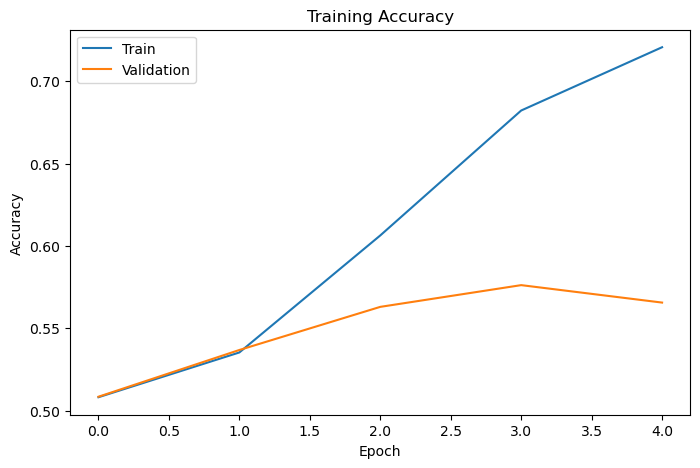

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

## Plot Loss Graph

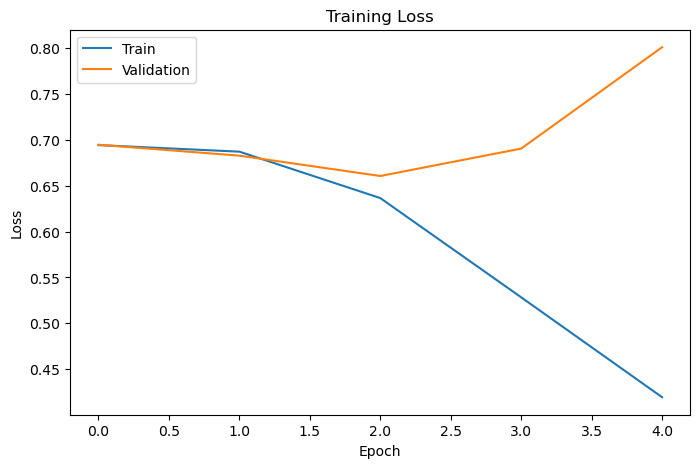

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

## Predict Sentiment for a Single Review

In [20]:
sample_review = X_test[10].reshape(1, -1)

prediction = model.predict(sample_review)

if prediction > 0.5:
    print("Positive Review ")
else:
    print("Negative Review ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Negative Review 
